In [ ]:
import wandb
import os

api = wandb.Api()

# # List all runs in your project
# runs = api.runs("weissma6-zhaw-school-of-engineering/UR10_pick_ppo")

# print("Available runs:")
# for run in runs:
#     print(f"  ID: {run.id}  |  Name: {run.name}  |  State: {run.state}")


# '''
# This will show you the exact run IDs. Common issues:

# 1. **Run name ≠ Run ID** — W&B has both `run.name` (display name) and `run.id` (unique identifier). You might be using the name instead of the ID.

# 2. **Check in W&B UI** — Go to your run's page, the URL will §be:

# https://wandb.ai/weissma6/UR10_pick_ppo/runs/<actual_run_id>
'''

wandb: Currently logged in as: weissma6 (weissma6-zhaw-school-of-engineering) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Available runs:
  ID: ps4ihqb6  |  Name: Test new geometry  |  State: finished
  ID: 1zp7tde5  |  Name: Tiny1  |  State: finished
  ID: 8usag8a4  |  Name: Tiny1  |  State: finished
  ID: m835o1hp  |  Name: fast  |  State: finished
  ID: quickest_20260117_092424_623  |  Name: quickest_20260117_092424_623  |  State: finished
  ID: meaningful_video_20260117_102721_4575  |  Name: meaningful_video_20260117_102721_4575  |  State: finished
  ID: ncwu81wk  |  Name: default_short_seed 1  |  State: finished
  ID: el7qkkoe  |  Name: default_short_seed 1  |  State: finished
  ID: j2lk3gxw  |  Name: default_short_seed 1  |  State: finished
  ID: gjvguk4x  |  Name: default_short_seed 100k  |  State: finished
  ID: ikfi821b  |  Name: default_short_1k  |  State: finished
  ID: sweep_part2_1028_20260117_170531_7924  |  Name: sweep_part2_1028_20260117_170531_7924  |  State: finished
  ID: baseling_fast_20260118_104318_2201  |  Name: baseling_fast_20260118_104318_2201  |  State: finished
  ID: baseling_2

"\nThis will show you the exact run IDs. Common issues:\n\n1. **Run name ≠ Run ID** — W&B has both `run.name` (display name) and `run.id` (unique identifier). You might be using the name instead of the ID.\n\n2. **Check in W&B UI** — Go to your run's page, the URL will §be:\n\nhttps://wandb.ai/weissma6/UR10_pick_ppo/runs/<actual_run_id>\n"

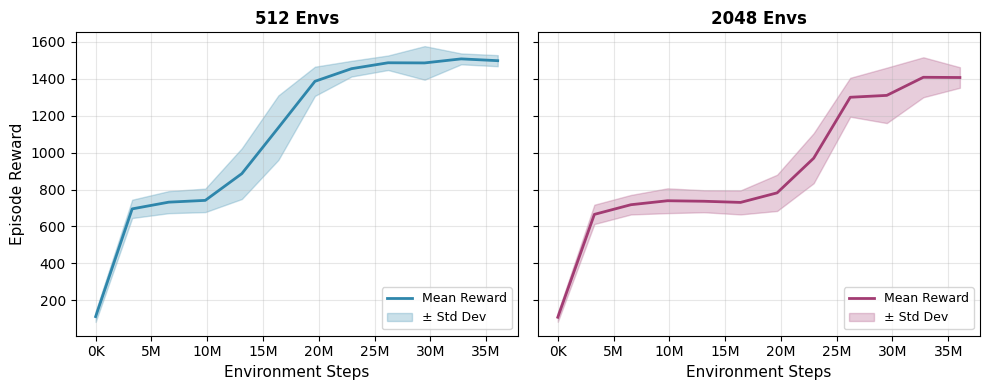

In [2]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Fetch data from W&B ---
api = wandb.Api()
user = "weissma6-zhaw-school-of-engineering"
project = "UR10_pick_ppo"
runs = {
    "512 Envs": "lift_512Envs_20260124_164012_5264",
    "2048 Envs": "lift_2048Envs_20260124_163951_172",
}

data = {}
for label, run_id in runs.items():
    run = api.run(f"{user}/{project}/{run_id}")
    history = run.history(keys=["eval/episode_reward", "eval/episode_reward_std"])
    history = history.dropna()  # Remove NaN rows
    data[label] = history

# --- Plot ---
fig, axes = plt.subplots(1, len(runs), figsize=(5 * len(runs), 4), sharey=True)

# Color palette (adjust as needed)
colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"]

for ax, (label, df), color in zip(axes, data.items(), colors):
    steps = df["_step"] if "_step" in df.columns else df.index
    mean = df["eval/episode_reward"]
    std = df["eval/episode_reward_std"]
    
    # Plot mean line
    ax.plot(steps, mean, color=color, linewidth=2, label="Mean Reward")
    
    # Plot std band
    ax.fill_between(
        steps,
        mean - std,
        mean + std,
        color=color,
        alpha=0.25,
        label="± Std Dev"
    )
    
    ax.set_xlabel("Environment Steps", fontsize=11)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)

    # Format x-axis with millions
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
    )

axes[0].set_ylabel("Episode Reward", fontsize=11)

plt.tight_layout()
plt.savefig("reward_comparison.pdf", bbox_inches="tight", dpi=300)
plt.savefig("reward_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

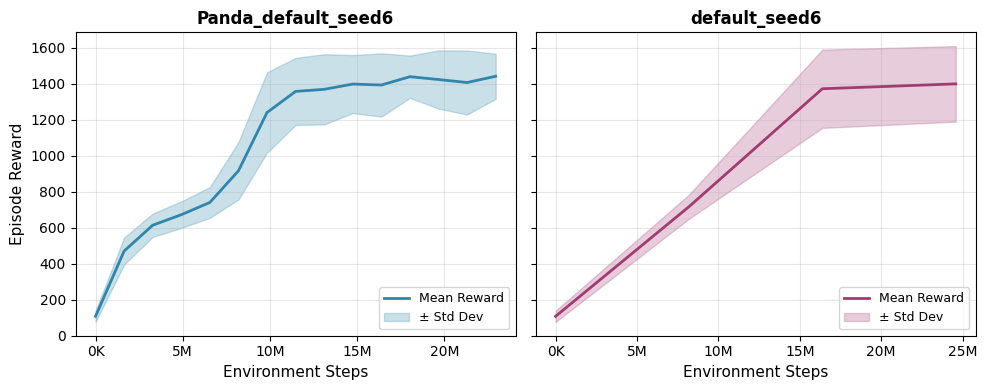

In [4]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Fetch data from W&B ---
api = wandb.Api()
user = "weissma6-zhaw-school-of-engineering"
project = "panda_pick_ppo"
runs = {
    "Panda_default_seed6": "2hcb0tlw",
    "default_seed6": "umm9hky6",
}
# "default_seed6": "umm9hky6",

data = {}
for label, run_id in runs.items():
    run = api.run(f"{user}/{project}/{run_id}")
    history = run.history(keys=["eval/episode_reward", "eval/episode_reward_std"])
    history = history.dropna()  # Remove NaN rows
    data[label] = history

# --- Plot ---
fig, axes = plt.subplots(1, len(runs), figsize=(5 * len(runs), 4), sharey=True)

# Color palette (adjust as needed)
colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"]

for ax, (label, df), color in zip(axes, data.items(), colors):
    steps = df["_step"] if "_step" in df.columns else df.index
    mean = df["eval/episode_reward"]
    std = df["eval/episode_reward_std"]
    
    # Plot mean line
    ax.plot(steps, mean, color=color, linewidth=2, label="Mean Reward")
    
    # Plot std band
    ax.fill_between(
        steps,
        mean - std,
        mean + std,
        color=color,
        alpha=0.25,
        label="± Std Dev"
    )
    
    ax.set_xlabel("Environment Steps", fontsize=11)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)

    # Format x-axis with millions
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
    )

axes[0].set_ylabel("Episode Reward", fontsize=11)

plt.tight_layout()
# plt.savefig("reward_comparison.pdf", bbox_inches="tight", dpi=300)
# plt.savefig("reward_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

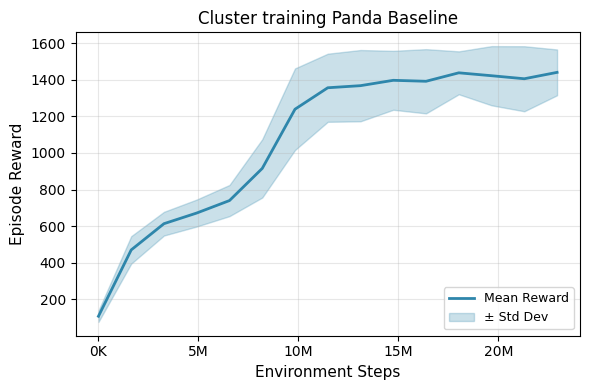

In [5]:
# --- Fetch data from W&B ---
api = wandb.Api()
user = "weissma6-zhaw-school-of-engineering"
project = "panda_pick_ppo"
label = "Panda_default_seed6"
run_id = "2hcb0tlw"

run = api.run(f"{user}/{project}/{run_id}")
df = run.history(keys=["eval/episode_reward", "eval/episode_reward_std"]).dropna()

SAVE_DIR = "run_graphs/"
RUN_DIR = os.path.join(SAVE_DIR, label)

fig, ax = plt.subplots(figsize=(6, 4))

label, df = list(data.items())[0]
color = "#2E86AB"

steps = df["_step"] if "_step" in df.columns else df.index
mean = df["eval/episode_reward"]
std = df["eval/episode_reward_std"]

ax.plot(steps, mean, color=color, linewidth=2, label="Mean Reward")
ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.25, label="± Std Dev")

ax.set_xlabel("Environment Steps", fontsize=11)
ax.set_ylabel("Episode Reward", fontsize=11)
ax.set_title("Cluster training Panda Baseline", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=9)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
)

plt.savefig(os.path.join(RUN_DIR, 'Training_Reward.png'), dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
def plot_training_reward(user, project, run_id, title=None, save_dir="run_graphs", color="#2E86AB"):
    api = wandb.Api()
    run = api.run(f"{user}/{project}/{run_id}")
    df = run.history(keys=["eval/episode_reward", "eval/episode_reward_std"]).dropna()

    run_dir = os.path.join(save_dir, run_id)
    os.makedirs(run_dir, exist_ok=True)

    steps = df["_step"] if "_step" in df.columns else df.index
    mean = df["eval/episode_reward"]
    std = df["eval/episode_reward_std"]

    # ── Collect runtime ──
    summary = run.summary
    runtime = summary.get("_runtime")
    if runtime:
        mins = runtime / 60
        runtime_str = f"Runtime: {mins:.1f} min ({runtime:.0f}s)"
    else:
        try:
            from datetime import datetime
            t0 = datetime.fromisoformat(run.created_at.replace("Z", "+00:00"))
            t1 = datetime.fromisoformat((run.heartbeat_at or run.updated_at).replace("Z", "+00:00"))
            mins = (t1 - t0).total_seconds() / 60
            runtime_str = f"Duration: {mins:.0f} min"
        except:
            runtime_str = "Runtime: N/A"

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(steps, mean, color=color, linewidth=2, label="Mean Reward")
    ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.25, label="± Std Dev")
    ax.set_xlabel("Environment Steps", fontsize=11)
    ax.set_ylabel("Episode Reward", fontsize=11)
    ax.set_title(title or run.name, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
    )

    ax.text(0.5, -0.22, runtime_str, transform=ax.transAxes,
            ha="center", fontsize=9, color="gray", style="italic")

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.22)
    plt.savefig(os.path.join(run_dir, "Training_Reward.png"), dpi=300, bbox_inches="tight")
    plt.show()
    return None

In [ ]:
# # List all runs in your project
# runs = api.runs("weissma6-zhaw-school-of-engineering/ur10_pick_ppo")

# print(f"Last 10 runs:\n")
# print(f"  {'Run ID':<40} {'Name':<50} {'State'}")
# print(f"  {'─'*40} {'─'*50} {'─'*10}")
# for run in list(runs)[-10:]:
#     print(f"  {run.id:<40} {run.name:<50} {run.state}")

Last 10 runs:

  Run ID                                   Name                                               State
  ──────────────────────────────────────── ────────────────────────────────────────────────── ──────────
  frcR=100_Damp=2_torfric_0.1_DR_M_20260208_163802_3886 frcR=100_Damp=2_torfric_0.1_DR_M_20260208_163802_3886 finished
  frcR=100_Damp=2_torfric_0.1_DR_FR_20260208_163807_3590 frcR=100_Damp=2_torfric_0.1_DR_FR_20260208_163807_3590 finished
  4001_FR130_limp0.990.995_Damp=0.5_DR_MFR_20260208_170951_9961 4001_FR130_limp0.990.995_Damp=0.5_DR_MFR_20260208_170951_9961 finished
  4001_FR130_limp0.990.995_Damp=0.5_DR_M_20260208_170954_8986 4001_FR130_limp0.990.995_Damp=0.5_DR_M_20260208_170954_8986 finished
  4001_FR130_limp0.990.995_Damp=0.5_DR_off_20260208_170954_8864 4001_FR130_limp0.990.995_Damp=0.5_DR_off_20260208_170954_8864 finished
  4001_FR130_limp0.990.995_Damp=0.5_DR_FR_20260208_170958_525 4001_FR130_limp0.990.995_Damp=0.5_DR_FR_20260208_170958_525 finished
  Damp=2

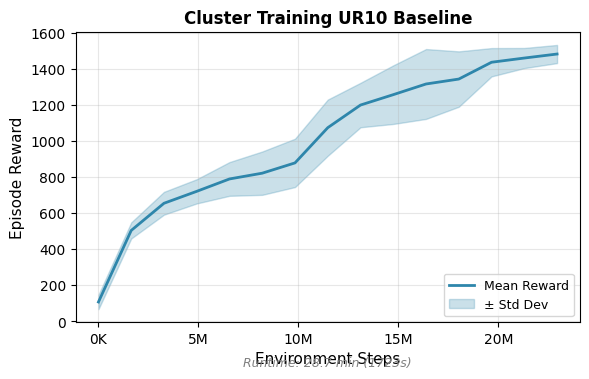

In [10]:
plot_training_reward(
    user="weissma6-zhaw-school-of-engineering",
    project="ur10_pick_ppo",
    run_id="4001_FR130_limp0.990.995_Damp=0.5_DR_off_20260208_170954_8864",
    title="Cluster Training UR10 Baseline",
)